# Correlation maps - SSS vs SIC

In [30]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cartopy.crs as ccrs
from scipy.stats import t
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [31]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40747")
client

<Client: 'tcp://127.0.0.1:40747' processes=8 threads=32, memory=123.95 GiB>

In [32]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [33]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [34]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [35]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [36]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## Select days after sea ice minimum each year and mask SIC>15%

In [37]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [38]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [39]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [40]:
# select days after sea ice minimum for SIC and salinity

# select all timesteps after sea ice minimum each year
ice_yrs = ice_beaufort.sel(time=full_date_array)
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,7)) # only upper 10 m

In [41]:
# look at depth of grid cell center and bottom of grid cell
print(salt_yrs.Z.values)
print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

[-0.5   -1.57  -2.79  -4.185 -5.78  -7.595 -9.66 ]
[ -1.    -2.14  -3.44  -4.93  -6.63  -8.56 -10.76]


In [42]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = ice_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = ice_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(ice_yrs * 0)  # Align time with ice_yrs

# apply mask to sea ice ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)
ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)

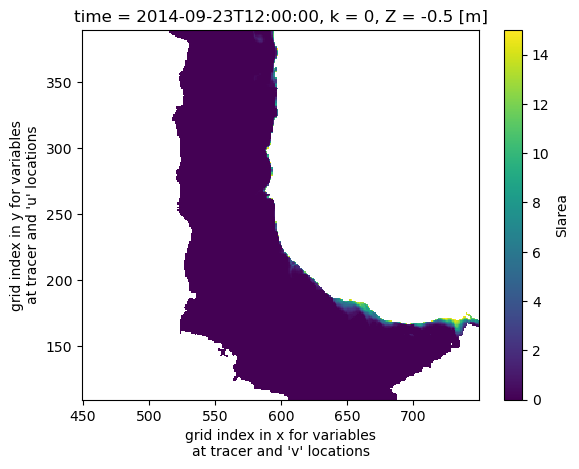

In [17]:
ice_yrs_masked.sel(time='2014').isel(time=0).plot();

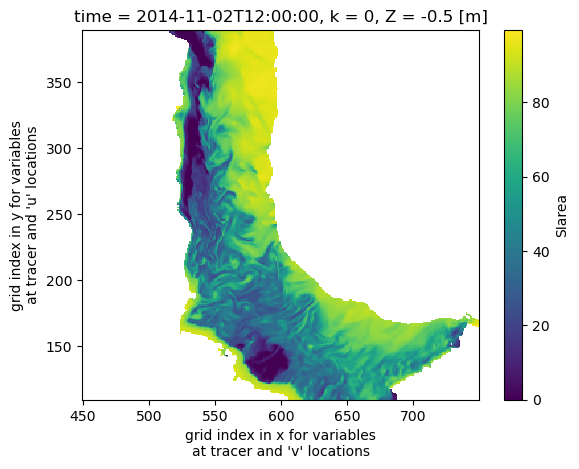

In [18]:
ice_yrs_masked.sel(time='2014').isel(time=40).plot();

## Calculate FWC

In [43]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [44]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

# dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8)) # upper 12
dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,7)) # upper 10
fwc_beaufort_yrs = calculate_fwc(salt_yrs, salt_ref, dz)

In [45]:
# mask land grid cells and where SIC>15% on ice minimum date
# ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

In [22]:
# determine the upper end of the dataset
fwc_yrs_masked.max().values

array(6.75552669)

In [23]:
# check shape of each dataset
print(fwc_yrs_masked.shape)
print(ice_yrs_masked.shape)

(733, 280, 300)
(733, 280, 300)


## Linear regression

In [25]:
fwc_over_2m = fwc_yrs_masked.where(fwc_yrs_masked>2)

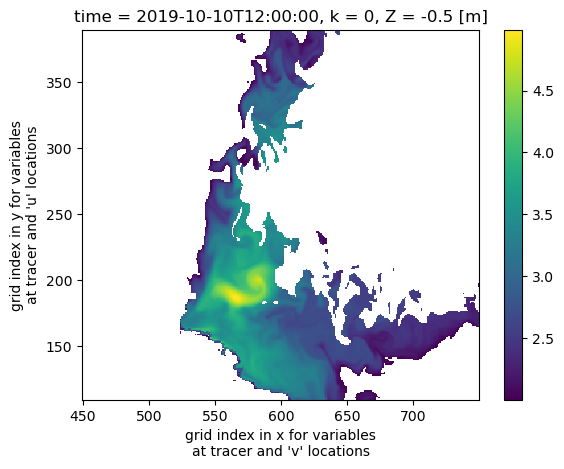

In [28]:
fwc_over_2m.sel(time='2019-10-10').plot();

## DOY of sea ice onset

In [19]:
def find_ice_onset_doy(sic, threshold=15, duration=3):
    # Convert to binary mask: 1 if SIC >= threshold, else 0
    ice_mask = sic >= threshold

    # Rolling sum over time to find 3-day periods over threshold
    ice_rolling = ice_mask.rolling(time=duration, center=False).sum()

    # First time index where the rolling sum equals duration (i.e., 3 consecutive days over threshold)
    condition_met = (ice_rolling >= duration)

    # Find the first time index this condition is True
    def first_true_doy(x, time_coords):
        if not np.any(x):
            return np.nan
        first_index = np.argmax(x)
        return pd.to_datetime(time_coords[first_index]).dayofyear

    # Apply over grid cells
    doy = xr.apply_ufunc(
        first_true_doy,
        condition_met,
        condition_met['time'],
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[]],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
    )

    return doy

In [62]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 3D xarray.DataArray (time, i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('time', 'i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('time', 'i', 'j').
    """
    rotated = np.rot90(da,3,axes=[0,1])
    
    out = xr.DataArray(
        data=rotated,
        dims=('i','j'),
        coords={
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [40]:
# masked ds
doy_ice_onset = find_ice_onset_doy(ice_yrs_masked.sel(time='2018').chunk(dict(time=-1)), threshold=15, duration=3)

In [78]:
# from September 1 on
ice_past_september = ice_beaufort.sel(time=ice_beaufort['time'].dt.month >= 9)
doy_ice_onset = find_ice_onset_doy(ice_past_september.sel(time='2018').chunk(dict(time=-1)), threshold=15, duration=3)

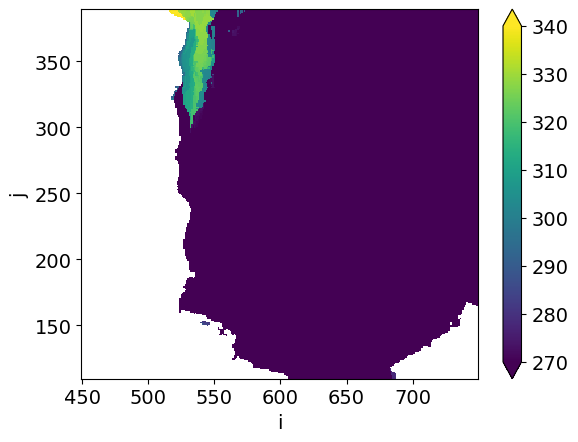

In [82]:
doy_ice_onset.plot(vmin=270,vmax=340);

In [41]:
# Rotate the fields so that alaska is on the bottom
doy_ice_onset_rot = rotate_dataarray_90ccw(doy_ice_onset)

In [78]:
HH_grid_land_rot = rotate_dataarray_90ccw(HH_land_beaufort)

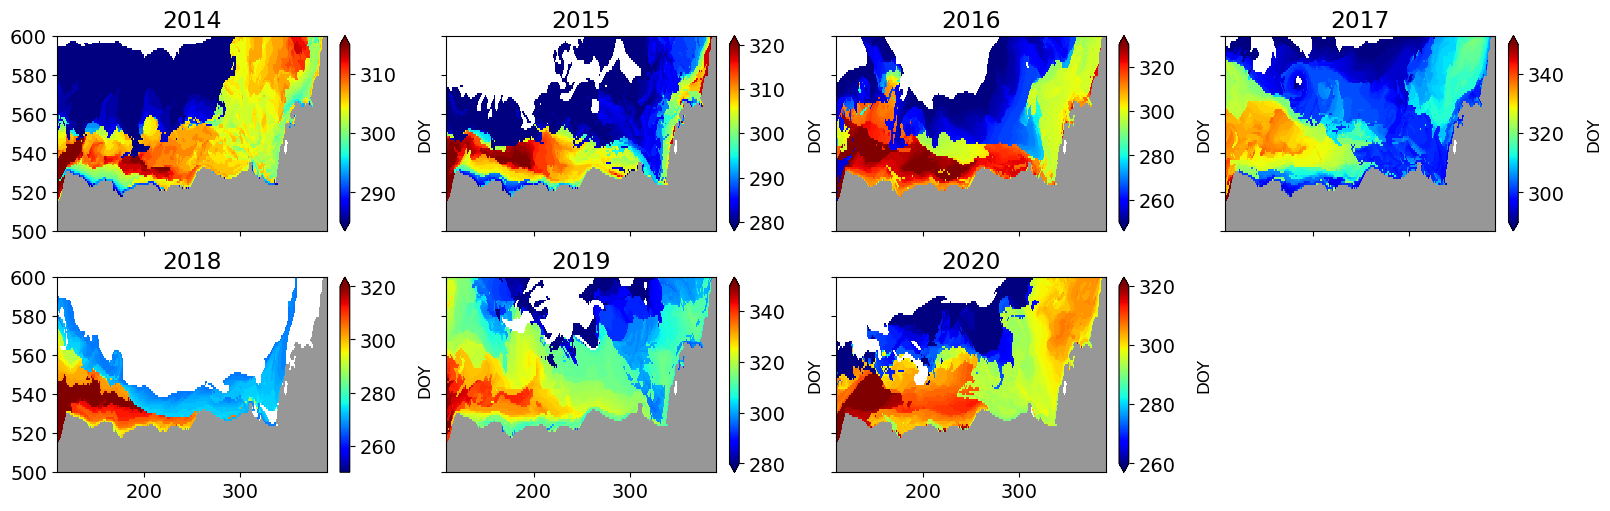

In [88]:
years = np.arange(2014, 2021)
n_years = len(years)

# 2 rows, 4 columns (1 unused)
fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=[16, 5], layout='constrained')
plt.rcParams['font.size'] = 14
axs = axs.flatten()

for i, year in enumerate(years):
    ax = axs[i]

    # Compute DOY when SIC > 15% for 3+ days
    doy_ice_onset = find_ice_onset_doy(
        ice_yrs_masked.sel(time=str(year)).chunk(dict(time=-1)),
        threshold=15, duration=3
    )

    # Rotate so Alaska is at bottom
    doy_ice_onset_rot = rotate_dataarray_90ccw(doy_ice_onset)

    # Define vmin and vmax ranges in a dictionary
    vmin_vmax_dict = {
        0: (285, 315),
        1: (280, 320),
        2: (250, 330),
        3: (290, 350),
        4: (250, 320),
        5: (280, 350),
        6: (260, 320)
    }
    
    # Use the dictionary to get the correct vmin and vmax for each plot
    vmin, vmax = vmin_vmax_dict.get(i, (None, None))
    
    pcm = doy_ice_onset_rot.plot(ax=ax, vmin=vmin, vmax=vmax, cmap='jet')

    HH_grid_land_rot.plot(ax=ax, cmap='Greys_r', add_colorbar=False)

    # Set subplot title and clean axis labels
    ax.set_title(f"{year}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(500,600)

    # Get and label the colorbar
    if pcm.colorbar is not None:
        pcm.colorbar.set_label("DOY", rotation=90, labelpad=15, fontsize=12)

# Hide unused subplot
if n_years < len(axs):
    axs[-1].axis('off')

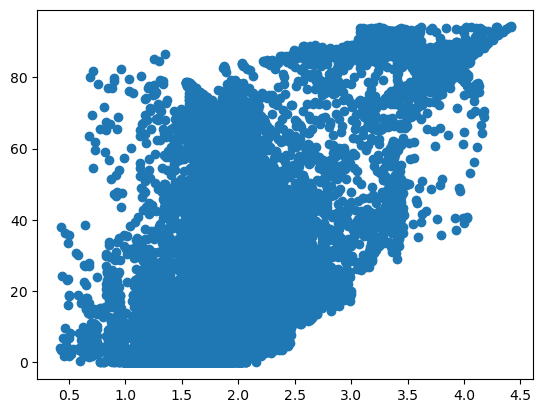

In [59]:
plt.scatter(fwc_yrs_masked.sel(time='2020-10-18'),ice_yrs_masked.sel(time='2020-10-18'));

In [ ]:
from scipy.stats import linregress

# Define a function to apply at each pixel
def pixel_linregress(fwc_1d, doy_1d):
    mask = np.isfinite(fwc_1d) & np.isfinite(doy_1d)
    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    slope, intercept, r_value, p_value, std_err = linregress(fwc_1d[mask], doy_1d[mask])
    return slope, intercept, r_value, p_value, std_err

# Apply across grid cells using apply_ufunc
results = xr.apply_ufunc(
    pixel_linregress,
    fwc,
    ice_doy,
    input_core_dims=[['time'], ['time']],
    output_core_dims=[[], [], [], [], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float, float, float, float, float],
)

# Create a dataset with the regression outputs
regression_ds = xr.Dataset({
    'slope': results[0],
    'intercept': results[1],
    'r': results[2],
    'p_value': results[3],
    'std_err': results[4],
})

# Optional: Mask areas with high p-values (e.g., p > 0.05)
significant_mask = regression_ds['p_value'] < 0.05
significant_slopes = regression_ds['slope'].where(significant_mask)

## Correlation coefficients for October of each year

In [51]:
def sig_corr(corr_da, n):
    """
    Determine which correlations are statistically significant
    Mask insignificant values in provided array and return only signficant values

    n : sample size
    corr_da : correlation coefficients
    """
    
    # compute the t-statistic
    t_stat = corr_da * np.sqrt((n - 2) / (1 - corr_da**2))

    # compute p-values using the survival function (1 - CDF)
    p_values = 2 * t.sf(np.abs(t_stat), df=n - 2)

    # determine significance at alpha=0.05
    alpha = 0.05
    # mask non-significant correlations
    corr_significant = corr_da.where(p_values < alpha)
    
    return corr_significant

In [26]:
# select only month of october for each year
fwc_oct_masked = fwc_yrs_masked.sel(time=fwc_yrs_masked['time'].dt.month == 10)
ice_oct_masked = ice_yrs_masked.sel(time=fwc_yrs_masked['time'].dt.month == 10)

In [38]:
corr_fwc_ice = xr.corr(fwc_oct_masked.sel(time='2019'), ice_oct_masked.sel(time='2019'), dim='time').compute()

In [39]:
significant_corr_fwc_ice = sig_corr(corr_fwc_ice, len(ice_oct_masked['time']))

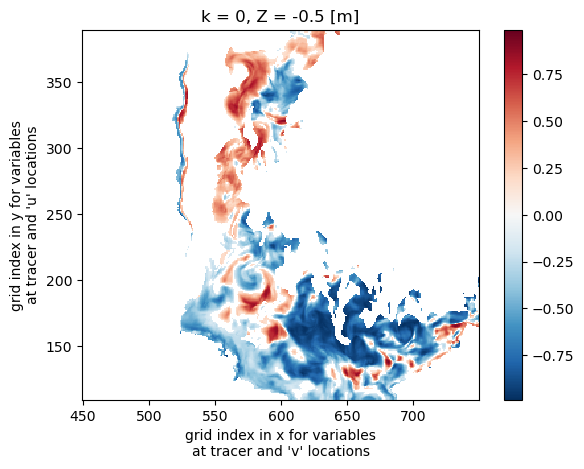

In [40]:
significant_corr_fwc_ice.plot();

## Plot time series of R2 for region each year

In [48]:
corr_fwc_sic = xr.corr(fwc_yrs_masked, ice_yrs_masked, dim=['i','j'])

In [52]:
significant_corr_fwc_sic = sig_corr(corr_fwc_sic, len(ice_yrs_masked['time']))

In [53]:
significant_corr_fwc_sic.sel(time='2019').max().values

array(0.58089615)

In [54]:
salt_yrs_masked = salt_yrs.where(land_sic_mask_yr)

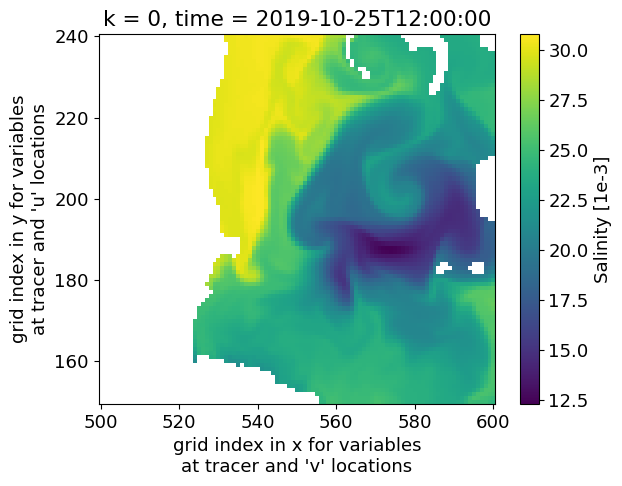

In [68]:
salt_yrs_masked.sel(time='2019-10-25',i=slice(500,600),j=slice(150,240)).isel(k=0,time=0).plot();
# ice_yrs_masked.sel(time='2019-10-25').isel(time=0).plot();

In [55]:
salt_box = salt_yrs_masked.sel(time='2019-10-25').isel(k=0,time=0)

In [56]:
ice_below_50_mask = ice_yrs_masked<50

In [57]:
ice_below_50 = ice_yrs_masked.where(ice_below_50_mask)
sss_below_50 = salt_yrs_masked.isel(k=0).where(ice_below_50_mask)

In [62]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 3D xarray.DataArray (time, i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('time', 'i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('time', 'i', 'j').
    """
    rotated = np.rot90(da,3,axes=[0,1])
    
    out = xr.DataArray(
        data=rotated,
        dims=('i','j'),
        coords={
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [65]:
# rotate arrays
sss_below_50_rot = rotate_dataarray_90ccw(sss_below_50.sel(time='2019-10-25').isel(time=0))
ice_below_50_rot = rotate_dataarray_90ccw(ice_below_50.sel(time='2019-10-25').isel(time=0))

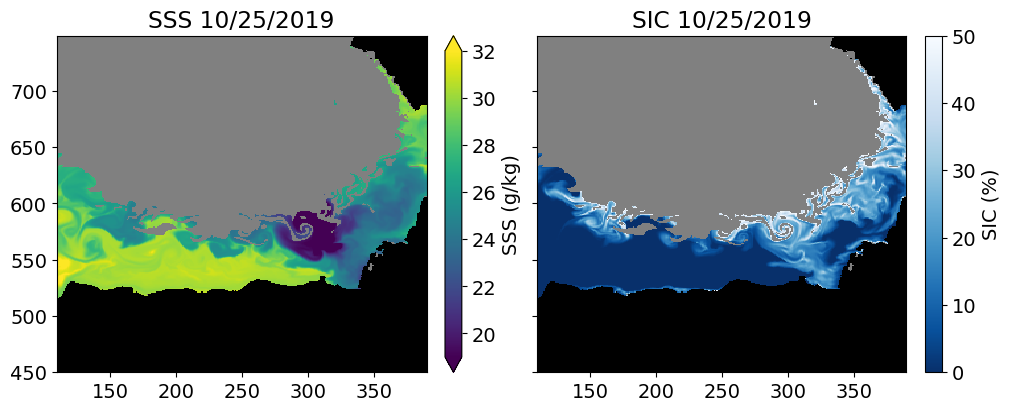

In [92]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=[10, 4], layout='constrained')
plt.rcParams['font.size'] = 14

sss_below_50_rot.plot(ax=ax1,vmin=19,vmax=32, cbar_kwargs={'label':'SSS (g/kg)'});
ice_below_50_rot.plot(ax=ax2,vmin=0,vmax=50,cmap='Blues_r', cbar_kwargs={'label':'SIC (%)'});

HH_grid_land_rot.plot(ax=ax1, cmap='Greys_r', vmin=0,vmax=1, add_colorbar=False)
HH_grid_land_rot.plot(ax=ax2, cmap='Greys_r', vmin=0,vmax=1, add_colorbar=False);

ax1.set_ylabel("")
ax2.set_ylabel("")
ax1.set_xlabel("")
ax2.set_xlabel("");

ax1.set_title("SSS 10/25/2019")
ax2.set_title("SIC 10/25/2019")

ax1.set_facecolor('Gray')
ax2.set_facecolor('Gray')

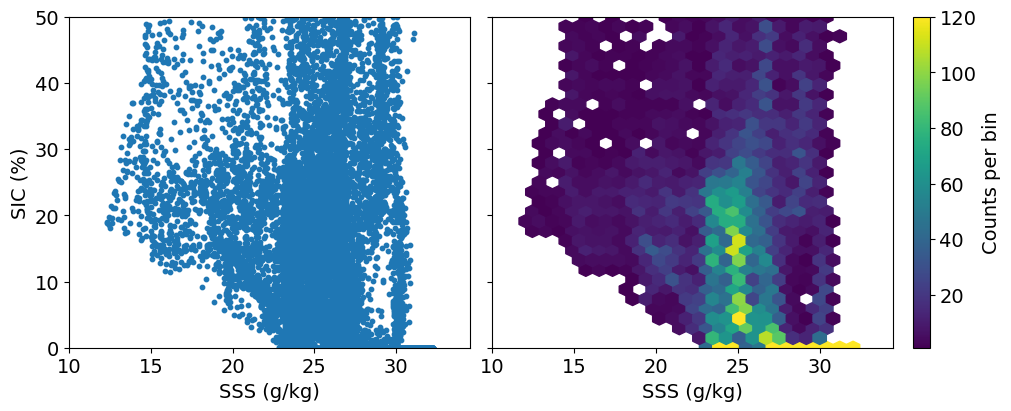

In [104]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=[10, 4], layout='constrained')
plt.rcParams['font.size'] = 14

extent = [10,34.5,0,50]
ax1.scatter(sss_below_50_rot.values, ice_below_50_rot.values,s=10);
cbar_temp = ax2.hexbin(sss_below_50_rot.values, ice_below_50_rot.values, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=120)

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax2)
cbar.ax.set_ylabel('Counts per bin');

ax1.set_ylim(0,50)
ax1.set_xlim(10,34.5)

ax1.set_ylabel("SIC (%)")
ax2.set_ylabel("")
ax1.set_xlabel("SSS (g/kg)")
ax2.set_xlabel("SSS (g/kg)");

In [108]:
sss_below_50_rot

<xarray.DataArray 'SALT' (i: 300, j: 280)> Size: 672kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * i        (i) int32 1kB 450 451 452 453 454 455 ... 744 745 746 747 748 749
  * j        (j) int32 1kB 110 111 112 113 114 115 ... 384 385 386 387 388 389

In [111]:
sss_below_50_rot_plume = sss_below_50_rot.sel(i=slice(500,610),j=slice(275,350))
ice_below_50_rot_plume = ice_below_50_rot.sel(i=slice(500,610),j=slice(275,350))

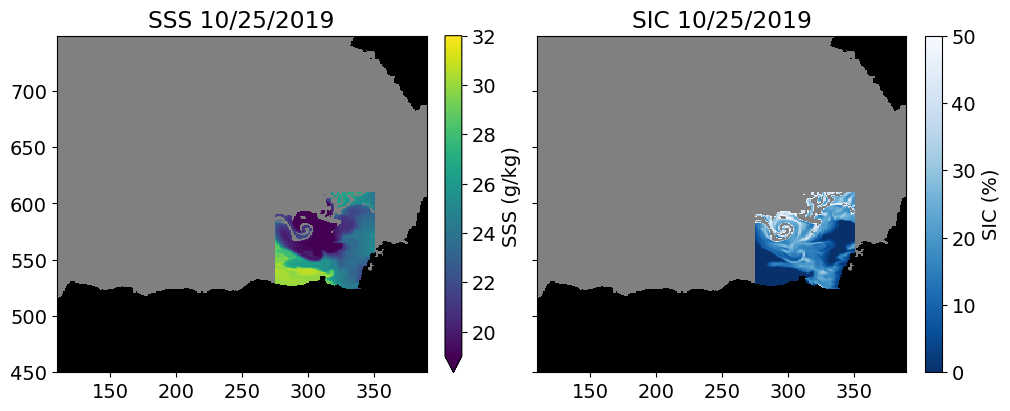

In [113]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=[10, 4], layout='constrained')
plt.rcParams['font.size'] = 14

sss_below_50_rot_plume.plot(ax=ax1,vmin=19,vmax=32, cbar_kwargs={'label':'SSS (g/kg)'});
ice_below_50_rot_plume.plot(ax=ax2,vmin=0,vmax=50,cmap='Blues_r', cbar_kwargs={'label':'SIC (%)'});

HH_grid_land_rot.plot(ax=ax1, cmap='Greys_r', vmin=0,vmax=1, add_colorbar=False)
HH_grid_land_rot.plot(ax=ax2, cmap='Greys_r', vmin=0,vmax=1, add_colorbar=False);

ax1.set_ylabel("")
ax2.set_ylabel("")
ax1.set_xlabel("")
ax2.set_xlabel("");

ax1.set_title("SSS 10/25/2019")
ax2.set_title("SIC 10/25/2019")

ax1.set_facecolor('Gray')
ax2.set_facecolor('Gray')

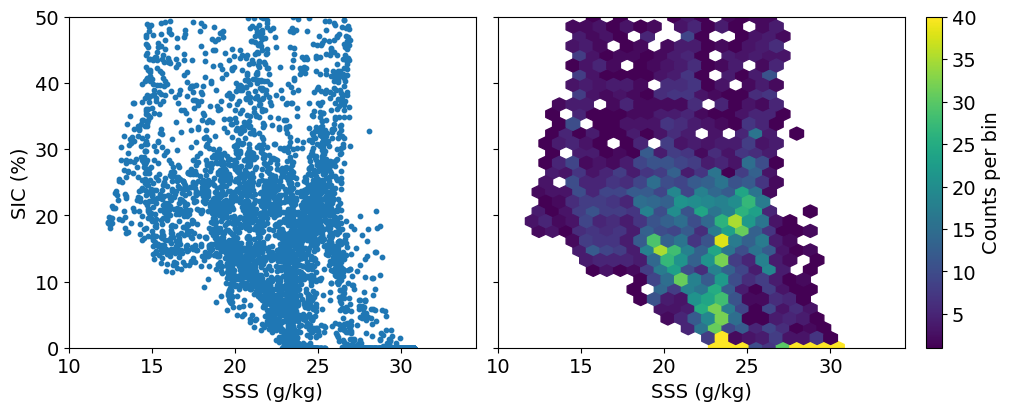

In [116]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=[10, 4], layout='constrained')
plt.rcParams['font.size'] = 14

extent = [10,34.5,0,50]
ax1.scatter(sss_below_50_rot_plume.values, ice_below_50_rot_plume.values,s=10);
cbar_temp = ax2.hexbin(sss_below_50_rot_plume.values, ice_below_50_rot_plume.values, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=40)

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax2)
cbar.ax.set_ylabel('Counts per bin');

ax1.set_ylim(0,50)
ax1.set_xlim(10,34.5)

ax1.set_ylabel("SIC (%)")
ax2.set_ylabel("")
ax1.set_xlabel("SSS (g/kg)")
ax2.set_xlabel("SSS (g/kg)");

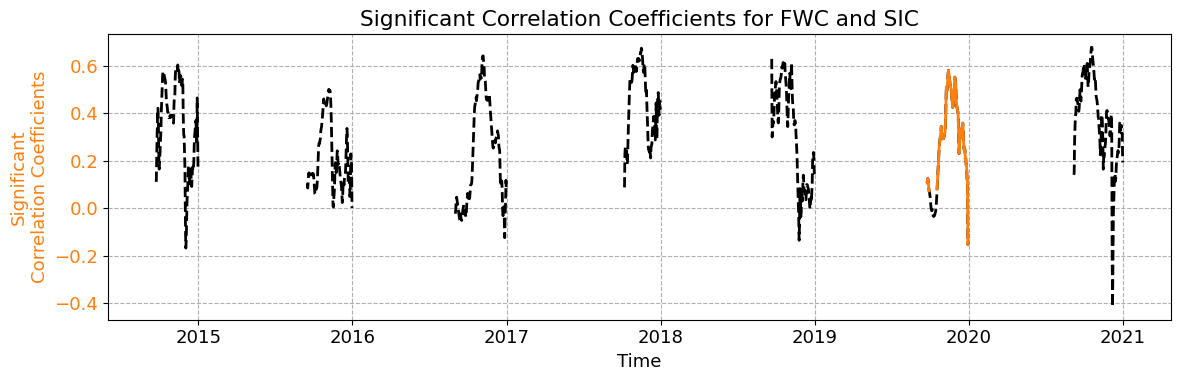

In [93]:
# Create a plot of coeff and sea ice cover
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(12, 4))

# Plot correlation coefficients on the primary axis
# corr_fwc_sic.plot(ax=ax1, color='k', linestyle='dashed', label='Correlation Coefficients', linewidth=2)
corr_fwc_sic_fill.plot(ax=ax1, color='k', linestyle='dashed', label='Correlation Coefficients', linewidth=2)
significant_corr_fwc_sic.sel(time='2019').plot(ax=ax1, color='tab:orange', label='Correlation Coefficients', linewidth=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Significant\nCorrelation Coefficients', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(linestyle='dashed')

# Create secondary axis for sea ice area
# ax2 = ax1.twinx()  # Create a second y-axis
# SIcover_beaufort_percent.plot(ax=ax2, color='tab:blue', label='Sea Ice Cover (%)', linewidth=2)
# ax2.set_ylabel('Sea Ice Cover (%)', color='tab:blue')
# ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add a title and show the plot
ax1.set_title(r'Significant Correlation Coefficients for FWC and SIC')
# ax2.set_title("")
fig.tight_layout()

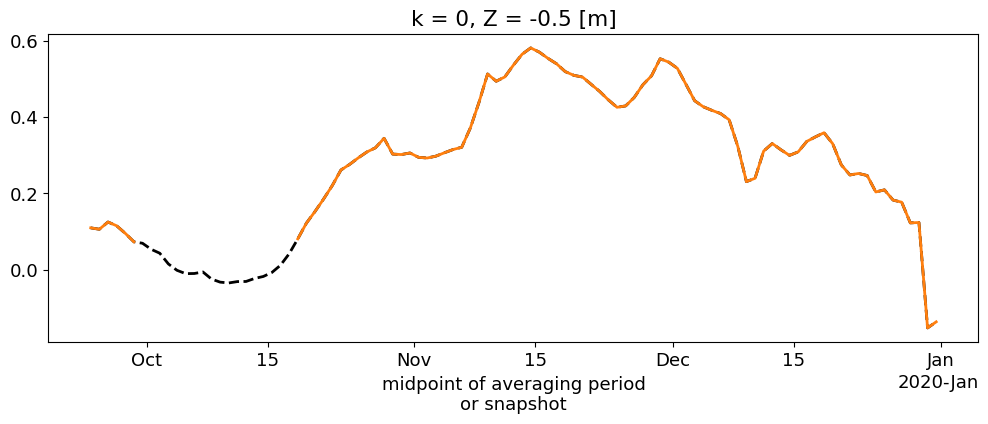

In [88]:
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(12, 4))

corr_fwc_sic.sel(time='2019').plot(ax=ax1, color='k', linestyle='dashed', label='Correlation Coefficients', linewidth=2)
significant_corr_fwc_sic.sel(time='2019').plot(ax=ax1, color='tab:orange', label='Correlation Coefficients', linewidth=2)